In [6]:
import pandas as pd

# Load the glass dataset
glass = pd.read_csv("glass.csv")
glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [7]:
glass.info()
glass.describe()
glass['Type'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

In [9]:
glass_binary = glass.copy()
glass_binary['Type'] = (glass_binary['Type'] == 1).astype(int)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = glass_binary.drop(columns=['Type'])
y = glass_binary['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

1. Try different thresholds for computing predictions. By default it is 0.5. Use predict_proba function to compute probabilities and then try custom thresholds and see their impact on Accuracy, Precision and Recall

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predict probabilities
probs = model.predict_proba(X_test_scaled)[:, 1]

for t in [0.3, 0.5, 0.7]:
    preds = (probs >= t).astype(int)
    print(f"\nThreshold = {t}")
    print("Accuracy :", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall   :", recall_score(y_test, preds))


Threshold = 0.3
Accuracy : 0.7441860465116279
Precision: 0.5
Recall   : 0.9090909090909091

Threshold = 0.5
Accuracy : 0.8372093023255814
Precision: 0.7
Recall   : 0.6363636363636364

Threshold = 0.7
Accuracy : 0.7906976744186046
Precision: 0.75
Recall   : 0.2727272727272727


In [ ]:
2. Do the same analysis for other columns

In [ ]:
y = 1 if Type == 2, else 0

In [16]:
# 1. Create new binary labels for Type 2
glass_bin2 = glass.copy()
glass_bin2['Type'] = (glass_bin2['Type'] == 2).astype(int)

# 2. Split data
X2 = glass_bin2.drop(columns=['Type'])
y2 = glass_bin2['Type']

from sklearn.model_selection import train_test_split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# 3. Scale features
from sklearn.preprocessing import StandardScaler
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

# 4. Train model
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression()
model2.fit(X2_train_scaled, y2_train)

# 5. Predict probabilities and evaluate thresholds
from sklearn.metrics import accuracy_score, precision_score, recall_score

probs2 = model2.predict_proba(X2_test_scaled)[:, 1]

for t in [0.3, 0.5, 0.7]:
    preds2 = (probs2 >= t).astype(int)
    print(f"\n[Type == 2] Threshold = {t}")
    print("Accuracy :", accuracy_score(y2_test, preds2))
    print("Precision:", precision_score(y2_test, preds2))
    print("Recall   :", recall_score(y2_test, preds2))


[Type == 2] Threshold = 0.3
Accuracy : 0.6046511627906976
Precision: 0.4482758620689655
Recall   : 0.9285714285714286

[Type == 2] Threshold = 0.5
Accuracy : 0.6976744186046512
Precision: 0.6
Recall   : 0.21428571428571427

[Type == 2] Threshold = 0.7
Accuracy : 0.6744186046511628
Precision: 0.0
Recall   : 0.0


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
3. Fit a Logistic Regression Model on all features. Remember to preprocess data (e.g., normalization and one-hot encoding).


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit logistic regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
4.  Plot ROC Curves for each model

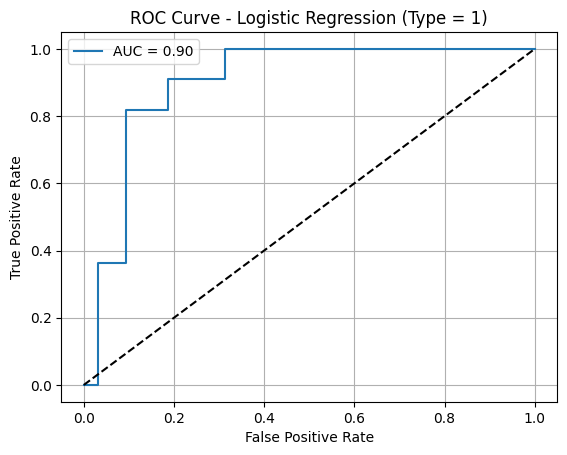

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Type = 1)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
5. Repeat the above exercise for different values of k

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Prepare the data (remove target column)
X_clust = glass.drop(columns=['Type'])

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# Run KMeans for different k values
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)
    print(f"k = {k} | Inertia = {inertia:.2f} | Silhouette Score = {silhouette:.2f}")

k = 2 | Inertia = 1558.97 | Silhouette Score = 0.40
k = 3 | Inertia = 1239.42 | Silhouette Score = 0.36
k = 4 | Inertia = 1057.41 | Silhouette Score = 0.39
k = 5 | Inertia = 932.91 | Silhouette Score = 0.31
k = 6 | Inertia = 792.67 | Silhouette Score = 0.33
k = 7 | Inertia = 712.52 | Silhouette Score = 0.34
k = 8 | Inertia = 669.60 | Silhouette Score = 0.32
k = 9 | Inertia = 584.98 | Silhouette Score = 0.34
k = 10 | Inertia = 533.17 | Silhouette Score = 0.35


In [ ]:
i. How do the inertia and silhouette scores change?

In [ ]:
Inertia always decreases as k increases, because more clusters means tighter grouping.
	•	Silhouette score typically increases initially and then drops — peaking at a k where the clusters are both dense and well-separated.
	•	You can plot both to visualize the “elbow” and optimal silhouette:

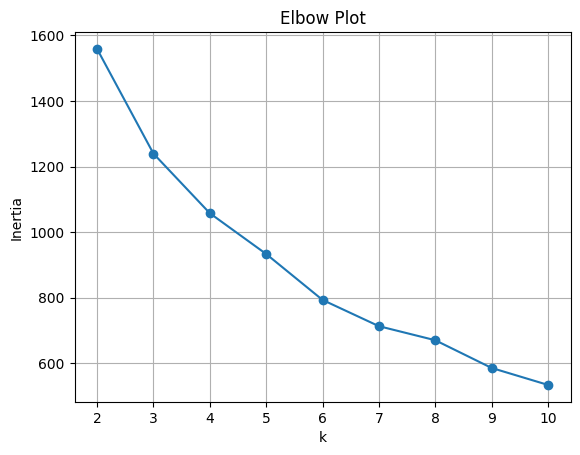

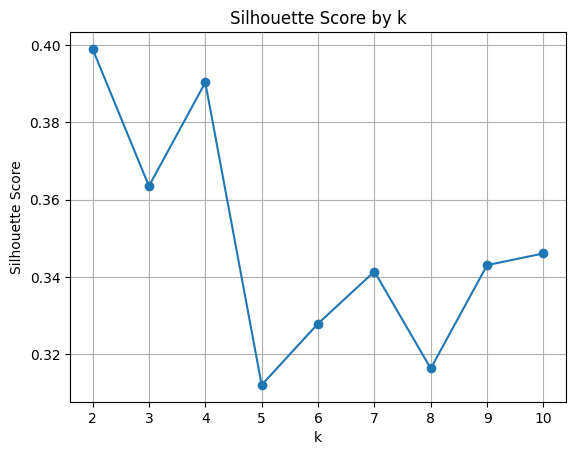

In [18]:
inertias = []
silhouettes = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plotting
import matplotlib.pyplot as plt

plt.plot(range(2, 11), inertias, marker='o', label="Inertia")
plt.title("Elbow Plot")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid()
plt.show()

plt.plot(range(2, 11), silhouettes, marker='o', label="Silhouette")
plt.title("Silhouette Score by k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

In [ ]:
ii. What if you don’t scale your features?

In [ ]:
If you skip scaling, features with large numeric ranges (like Si, Ca) will dominate the distance calculation, leading to biased clustering.


In [19]:
# Without scaling
kmeans_raw = KMeans(n_clusters=3, random_state=42)
labels_raw = kmeans_raw.fit_predict(X_clust)

sil_raw = silhouette_score(X_clust, labels_raw)
print(f"Silhouette Score (unscaled): {sil_raw:.2f}")

Silhouette Score (unscaled): 0.37


In [ ]:
iii. is there a “right” k? Why or why not?

In [ ]:
There’s no single “right” k, but there are ways to choose a good one:
	•	Elbow method (look for sharp drop in inertia)
	•	Max silhouette score
	•	Domain knowledge (e.g., 3 known glass categories?)
	•	Consistency of cluster assignments across k values

You choose the k that gives:
	•	Good separation between clusters
	•	High internal similarity
	•	Practical interpretability